In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Maximum likelihood polynomial regression

Polynomials can be written in terms of monomial basis functions $[1, x, x^2, \cdots, x^d]$ as

$$ f(x) = a_0 + a_1x + a_2 x^2 + \cdots + a_d x^d. $$

The degree $d$ of the polynomial refers to the highest exponent of the independent variable $x$ in the expression. This can be viewed as a linear model where the parameters are the polynomial coefficients which we can collect into a vector as

$$ \theta = [a_0, a_1, a_2, \cdots, a_d]^\dagger,  $$

where the superscript $\dagger$ indicates transpose i.e. $\theta$ should be viewed as a column vector of length $d+1$. $m = d+1$ is also sometimes referred to as the order of the polynomial. Notice that the polynomial expression above can be written as

$$ f(x) = \begin{bmatrix} 1 & x & x^2 & \cdots & x^d \end{bmatrix} \theta. $$

You have been provided with a data file called $\texttt{polynomial\_data.npz}$ that contains a dictionary with three vectors viz. the data $\texttt{y}$, the corresponding $\texttt{x}$ coordinate and the standard deviation of each data point $\texttt{stdev}$. It can be loaded using the $\texttt{np.load}$ function. Load the data and do the following:

1. Report the number of data points (henceforth referred to as $n$). (1 mark)
2. Plot $y$ vs. $x$ with errorbars using the $\texttt{plt.errorbar}$ function. (2 marks)
3. Label the axes and provide a legend. (1 mark)

 1- The number of data points is (100,)


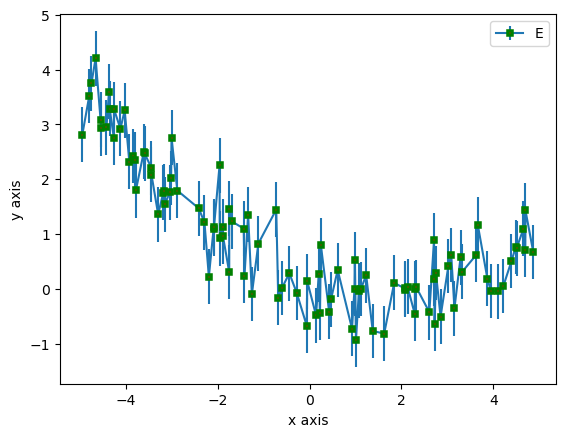

In [101]:
# answer 1, 2 and 3 here
#np.load('𝚙𝚘𝚕𝚢𝚗𝚘𝚖𝚒𝚊𝚕_𝚍𝚊𝚝𝚊.𝚗𝚙𝚣')
data = np.load('polynomial_data.npz')
print(f" 1- The number of data points is {np.shape(data['x'])}")
plt.errorbar(data['x'], data['y'], data['stdev'], marker='s', mfc='red',
                     mec='green', ms=2, mew=4)
plt.legend("Error")
plt.xlabel("x axis")
plt.ylabel("y axis")
plt.show()

In [23]:
data['y']

NpzFile 'polynomial_data.npz' with keys: x, y, stdev

In [47]:
help(plt.errorbar)

Help on function errorbar in module matplotlib.pyplot:

errorbar(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    yerr: 'float | ArrayLike | None' = None,
    xerr: 'float | ArrayLike | None' = None,
    fmt: 'str' = '',
    *,
    ecolor: 'ColorType | None' = None,
    elinewidth: 'float | None' = None,
    capsize: 'float | None' = None,
    barsabove: 'bool' = False,
    lolims: 'bool | ArrayLike' = False,
    uplims: 'bool | ArrayLike' = False,
    xlolims: 'bool | ArrayLike' = False,
    xuplims: 'bool | ArrayLike' = False,
    errorevery: 'int | tuple[int, int]' = 1,
    capthick: 'float | None' = None,
    data=None,
    **kwargs
) -> 'ErrorbarContainer'
    Plot y versus x as lines and/or markers with attached errorbars.

    *x*, *y* define the data locations, *xerr*, *yerr* define the errorbar
    sizes. By default, this draws the data markers/lines as well as the
    errorbars. Use fmt='none' to draw errorbars without any data markers.

    .. versionadded:: 3.7


## Measurement model and design matrix

In order to perform a linear regression we need to turn the linear model above into a measurement model of the form

$$ y = X \theta  + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma), $$

where $X$ is known as a design matrix. It can be constructed as follows:

$$ \underset{n \times d+1}{X} = \begin{bmatrix} 1 & x_0 & x_0^2 & \cdots & x_0^d \\
                                              1 & x_1 & x_1^2 & \cdots & x_1^d \\
                                              1 & x_2 & x_2^2 & \cdots & x_2^d \\
                                              \vdots & \vdots & \vdots & \cdots & \vdots \\
                                              1 & x_{n-1} & x_{n-1}^2 & \cdots & x_{n-1}^d \end{bmatrix},  $$

where the subscript labels the $i$-th data point. In other words, the $i$-th row of this matrix is $ X_i = [1 , x_i , x_i^2 , \cdots , x_i^d]$.

4. Explicitly construct this matrix as a $\texttt{numpy}$ array for a polynomial of degree $d=3$.  (3 marks)

In [67]:
# answer 4 here
x =  data['x']
y =  data['y']
len = data['x'].shape[0]
X = np.ones((len, 4))
for i in range(4):
    X[:, i] = x**i      
print(f"Shape of X is {X.shape}")

Shape of X is (100, 4)


5. Write down the likelihood for the problem given that $\epsilon$ is a realisation of Gaussian noise with covariance $\Sigma$. Remember to use a markdown cell. You can also write this on a piece of paper if you prefer.  (3 marks)

The likelihood for the problem takes the form

$$ p(y | x) = \frac{1}{\sqrt{(2\pi)^n |\Sigma|}} \exp\left(-\frac{1}{2}(y - \theta x)^\dagger \Sigma^{-1} (y - \theta x) \right). $$


In [ ]:
# answer 5 here (change the cell to Markdown cell)

6. Compute the maximum likelihood solution for the parameters $\theta$ assuming a polynomial of degree $d=3$. (Hint - you can use the normal equations for this, alternatively take the gradient of the negative log-likelihood and solve for $x$ after setting it to zero).  (5 marks)

In [109]:
from scipy.optimize import minimize
# since we'll be evaluating this function many times we provide a more efficient implementation
def sqexp2(r, sigmaf, l):  # here r = |t - tp|
    return sigmaf**2 * np.exp(-0.5 * r**2 / l**2)

def diffs(theta):
    return np.abs(y[:, None] - (thetax[None, :]))

def marginal_likelihood(theta, y):
    diff = diffs(theta)
    n = y.size
    sigmaf = theta[0]
    l = theta[1]
    Ky = sqexp2(diffs, sigmaf, l) + np.eye(n)*theta[2]**2
    u, s, v = np.linalg.svd(Ky, hermitian=True)
    logdetK = np.sum(np.log(s))
    Kyinv = u.dot(v/s.reshape(n, 1))
    alpha = Kyinv.dot(y)
    return np.vdot(y, alpha) + logdetK


# choose initial guess for hyper-parameters
theta0 = np.array([1.0, 1.0])
res = minimize(marginal_likelihood, theta0, args=(y), bounds=[(1e-3, None)])
print(res)

TypeError: unsupported operand type(s) for ** or pow(): 'function' and 'int'

In [ ]:
# answer 6 here


7. Now evaluate the inferred polynomial at the same input locations $x$ (i.e the same locations as where the data were obtained) and plot the result. Overlay the error bars on the same plot.  (2 marks)

NameError: name 'ti' is not defined

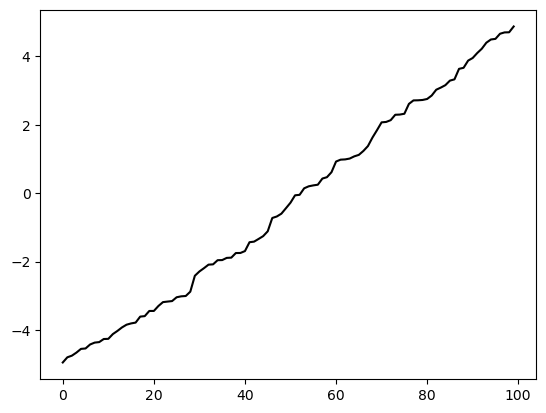

In [55]:
# answer 7 here
# let's plot the posterior mean and covariance
plt.plot(x ,'k', label='true function')
plt.plot(ti, xbar, 'b', label='posterior mean')
plt.fill_between(ti, xbar - np.sqrt(np.diag(D)), xbar + np.sqrt(np.diag(D)), color='b', alpha=0.2, label='posterior std')
plt.legend()

# Bayesian polynomial regression

If we also assume a zero mean Gaussian prior over $\theta$, say $P(\theta) = \mathcal{N}(0, K)$, we can write the posterior as

$$ \theta \sim \mathcal{N}\left( (X^\dagger \Sigma^{-1} X + K^{-1})^{-1} X^\dagger \Sigma^{-1} y, ~~ (X^\dagger \Sigma^{-1} X + K^{-1})^{-1} \right).  $$

In this special linear Gaussian case, we can find a closed form expression for the evidence $P(y)$. We will work with the negative log of the evidence since it is numerically more stable. It can be written as

$$ -\log P(y) = \log |\Sigma| + \log |K| - \log |D| - y^\dagger \Sigma^{-1} y - j^\dagger D j,  $$

where $j = X^\dagger \Sigma^{-1} y$ and $D = (K^{-1} + X^\dagger \Sigma^{-1} X)^{-1} $. 

You have been provided with a function called $\texttt{neg\_log\_evidence}$ which computes the evidence as a function of the polynomial degree in the cell below. Note that we are assuming that the prior covariance matrix is the identity i.e. $K = I$.

In [57]:
def neg_log_evidence(y, x, stdev, d):
    ''' 
    Function to compute negative log evidence
    Inputs:
        y       - data
        x       - x coordinates
        stdev   - standard deviations of each data point 
        d       - the degree of the polynomial
    '''
    # get j and D
    n = y.size
    m = d+1
    Phi = np.tile(x[:, None], (1, m))**np.arange(m)
    Sigmainv = np.eye(n)/stdev**2
    j = Phi.T.dot(Sigmainv.dot(y))
    K = np.eye(m)
    Dinv = np.linalg.inv(K) + Phi.T.dot(Sigmainv.dot(Phi))
    D = np.linalg.inv(Dinv)
    
    # get log determinant terms using Cholesky decomp
    sqrtD = np.linalg.cholesky(D + 1e-8*np.eye(m))
    logD = 2.0*np.sum(np.log(np.diag(sqrtD)))
    sqrtK = np.linalg.cholesky(K)
    logK = 2.0*np.sum(np.log(np.diag(sqrtK)))
    logSigma = -np.sum(np.log(np.diag(Sigmainv)))
    return logSigma + logK - logD - y.T.dot(Sigmainv.dot(y)) - j.T.dot(D.dot(j))

In [61]:
help(minimize)

Help on function minimize in module scipy.optimize._minimize:

minimize(
    fun,
    x0,
    args=(),
    method=None,
    jac=None,
    hess=None,
    hessp=None,
    bounds=None,
    constraints=(),
    tol=None,
    callback=None,
    options=None
)
    Minimization of scalar function of one or more variables.

    Parameters
    ----------
    fun : callable
        The objective function to be minimized::

            fun(x, *args) -> float

        where ``x`` is a 1-D array with shape (n,) and ``args``
        is a tuple of the fixed parameters needed to completely
        specify the function.

        Suppose the callable has signature ``f0(x, *my_args, **my_kwargs)``, where
        ``my_args`` and ``my_kwargs`` are required positional and keyword arguments.
        Rather than passing ``f0`` as the callable, wrap it to accept
        only ``x``; e.g., pass ``fun=lambda x: f0(x, *my_args, **my_kwargs)`` as the
        callable, where ``my_args`` (tuple) and ``my_kwargs`` (dic

8. Use the evidence to compute the optimal polynomial degree for the data provided. Report the result and store it for future usage. You may assume that it is no more than $d=4$. Remember that the maximum of the evidence will correspond to the minimum of the negative log evidence. (4 marks)

In [87]:
# answer 8 here
stdev = data["stdev"]
x =  data['x']
y =  data['y']
x0 = np.array([x[0], x[0], stdev[0]])
min = np.inf
for i in range(5):
    res = neg_log_evidence(x, y, stdev, i)
    if res < min :
        min = i
    
print(f"The optimal polynomial degree for the data provided is {min}")

The optimal polynomial degree for the data provided is 4


9. Now compute the posterior mean and covariance of the parameters $\theta$ using the optimal value of $d$. You may assume that the prior covariance is the identity $K=I$. (Hint - you have the explicit formulas for these in the cell labelled **Bayesian polynomial regression**).  (3 marks)

In [ ]:
# answer 9 here

10. Draw 10 samples of the parameters from the posterior (remember that you may have to add jitter when computing the Cholesky factor of the posterior covariance matrix). (4 marks)

In [ ]:
# answer 10 here

11. Evaluate the polynomial at 1000 points linearly spaced between the interval [-10, 10] using the samples obtained above and plot them all on the same plot. Also evaluate it using the mean value of $\theta$ and overlay this in black on the plot. Finally, overlay the error bars of the data. (4 marks)

In [ ]:
# answer 11 here